# DSM050 - Disaggregating Global Wealth-Welfare Trends

## Notebook setup

In [1]:
# Check current Python version
import sys
import warnings

EXPECTED_VERSION = (3, 13)

current_version = sys.version_info[:2]
if current_version != EXPECTED_VERSION:
    warnings.warn(
        f'Python version mismatch! Expected {EXPECTED_VERSION[0]}.{EXPECTED_VERSION[1]}, '
        f'but running on {current_version[0]}.{current_version[1]} instead.',
        UserWarning
    )

In [2]:
# Install the required packages
%pip install -qr requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import country_converter as coco
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import logging

logging.getLogger('country_converter').setLevel(logging.CRITICAL)

np.random.seed(42)

%matplotlib inline

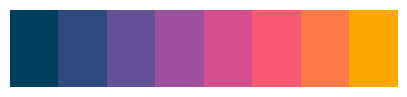

In [4]:
# Create a colour palette for visualisation
# https://www.learnui.design/tools/data-color-picker.html#palette
colours = [
    "#003f5c",
    "#2e4b7f",
    "#655197",
    "#9f509d",
    "#d44e90",
    "#fa5972",
    "#ff7a49",
    "#ffa600",
]

# Plot the custom colour map
custom_cmap = mcolors.ListedColormap(colours)
gradient = np.arange(len(colours)).reshape(1, -1)
fig, ax = plt.subplots(figsize=(5, 1))
ax.imshow(gradient, aspect='auto', cmap=custom_cmap)
ax.set_axis_off()

plt.show()

## Datasets

### World Countries - GeoJSON

Available at [ArcGIS - World Countries](https://hub.arcgis.com/datasets/esri::world-countries-generalized/about).

The GeoJSON file is a reasonably clean dataset and as such contains no missing values. However the dataset utilises the ISO2 standard of country codes, while our notebook will utilise ISO3. While ISO2 is commonly used, ISO3 provides more recognisable codes. Codes are utilised to provide a standard convention that is free from ambiguity that is common when using names, such as "South Africa" and "The Republic of South Africa".

Country datasets will commonly contain duplicates. This is usually when a country is disputed, such as Somaliland breaking away from Somalia. To handle this, we utilise GeoPanda's dissolve method which merges the geometries of observations utilising the same index. While this does eliminate information contained in the dataset, it prevents ambiguity when performing the analysis.

In [5]:
gdf_geometry = gpd.read_file("./data/World_Countries_(Generalized)_2173680399808997149.geojson")

assert gdf_geometry.isna().any(axis=1).sum() == 0, 'Country geometry source data should contain no null values.'

# Convert ISO2 to ISO3 and rename features for consistency
gdf_geometry["country_code"] = coco.convert(names=gdf_geometry["ISO"], to='ISO3')
gdf_geometry.set_index('country_code', inplace=True)
gdf_geometry = gdf_geometry[['geometry']]

print(f'Dimensions: {gdf_geometry.shape}')
print(f'Index type: {gdf_geometry.index.dtype}')
print(gdf_geometry.info())

print(f'Has duplicate indices: {gdf_geometry.index.has_duplicates}')

# Dissolve the geometries into single observations when countries are disputed. Unions the geometry.
gdf_geometry = gdf_geometry.dissolve(by=gdf_geometry.index)

print(f'Has duplicate indices after dissolving: {gdf_geometry.index.has_duplicates}')

gdf_geometry.sample(5)

Dimensions: (251, 1)
Index type: str
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 251 entries, AFG to ZWE
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  251 non-null    geometry
dtypes: geometry(1)
memory usage: 3.9+ KB
None
Has duplicate indices: True
Has duplicate indices after dissolving: False


,geometry
country_code,
BHS,"MULTIPOLYGON (((-75.77196 23.49972, -75.80528 ..."
ARE,"MULTIPOLYGON (((53.67805 24.16014, 53.66555 24..."
MYS,"MULTIPOLYGON (((111.29332 2.73334, 111.2954 2...."
TCA,"MULTIPOLYGON (((-71.15066 21.47073, -71.13219 ..."
SOM,"POLYGON ((45.86945 10.84416, 45.8975 10.83027,..."


## Country Income Bands

Available at [World Bank Group - Per Capita GDP](https://data.worldbank.org/indicator/NY.GDP.PCAP.CD).

The country income bands dataset contains observations for non-country entities, such as continents and regions. To handle these superfluous values, we restrict the datasat to only observations that have a matching ISO3 country code in the country geometries dataframe. This eliminates most missing values and limits the data to only entities pertinent to the analysis. However, there are still 2 observations with missing data. Since we cannot impute values, we will drop these observations.

In [6]:
file_path = "./data/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_273495.csv"
df_income = pd.read_csv(file_path, dtype=str)

kept_columns = ['Country Code', 'IncomeGroup']
df_income = df_income[kept_columns]

df_income.rename(columns={'Country Code': 'country_code', 'IncomeGroup': 'income'}, inplace=True)

# Retain only observations that match countries in the geometries dataset
df_income = df_income[df_income['country_code'].isin(gdf_geometry.index)]
df_income.set_index('country_code', inplace=True)

# Show any observations with missing values and drop them
print(df_income[df_income.isna().any(axis=1)])
df_income.dropna(inplace=True)

# Show dataset information
print(f'Dimensions: {df_income.shape}')
print(f'Index type: {df_income.index.dtype}')
print(df_income.info())

print(f'Has duplicate indices: {df_income.index.has_duplicates}')

# Convert the income to an ordinal
income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
ordinal_type = pd.CategoricalDtype(categories=income_order, ordered=True)
df_income['income'] = df_income['income'].astype(ordinal_type)

df_income.sample(5)

             income
country_code       
ETH             NaN
VEN             NaN
Dimensions: (211, 1)
Index type: str
<class 'pandas.DataFrame'>
Index: 211 entries, ABW to ZWE
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   income  211 non-null    str  
dtypes: str(1)
memory usage: 3.3+ KB
None
Has duplicate indices: False


,income
country_code,
GIB,High income
BWA,Upper middle income
COG,Lower middle income
AGO,Lower middle income
MLI,Low income


## Social Welfare Coverage

Here we have 2 datasets, from the International Labour Organisation and World Bank Group respectively. This is due to the sparcity of available data on social welfare coverage.

**International Labour Organisation**

Available at [ILOSTAT](https://rplumber.ilo.org/dataexplorer/?id=SDG_0131_SEX_SOC_RT_A).

This dataset contains several indicators and sources, thus we first filter the data to only those observations pertaining to the total percentage of each population covered by at least one social protection benefit.

The dataset uses country names instead of an ISO code, thus we convert the country names to ISO3 codes. This is subject to error as the conversion can make mistakes, such as converting both the "Southern Africa" region and the country "South Africa" to "ZAF". To manage this, we limit the data to the "ILO - Social Security Inquiry Database" as it contains country-based data. We then limit the dataset further to only observations matching a country geometry.

The dataset contains missing years in some countries, thus we use linear interpolation to impute missing values between two recorded years. We use this method due to the feature of interest being a continuous value that does not cease to change when unreported. An example of an instance when this is not the case would be stock prices over weekends when exchanges do not trade. In such cases we would use forward-filling of the last recorded value.


**World Bank Group**

Available at [World Bank Group - Coverage of social safety net programs](https://data.worldbank.org/indicator/per_sa_allsa.cov_pop_tot).

This dataset contains only the desired indicator albeit in an untidy format. In this case we melt the year values into "year" and "swf_pct" features. From here, we filter to known geometries and perform linear interpolation to impute missing values where possible.


**Unification**
Finally, we perform a join on the 2 datasets, using the World Bank Group data as the primary source. This is done in cases where both datasets contain values for the same year and country. In such a case, we prefer the World Bank Group data.

In [7]:
file_path = "./data/SDG_0131_SEX_SOC_RT_A-filtered-2026-06-23.csv"
df_swf_ilo = pd.read_csv(file_path)

# The dataset contains many different labels. Filter to the percentage of the population observations only.
df_swf_ilo = df_swf_ilo[df_swf_ilo["classif1.label"] == "Function: Population covered by at least one social protection benefit"]

# The dataset breaks down data by sex. We only want the totals.
df_swf_ilo = df_swf_ilo[df_swf_ilo["sex.label"] == "Total"]

# The dataset uses multiple sources. Limit to ILO - Social Security Inquiry Database as it contains country data
df_swf_ilo = df_swf_ilo[df_swf_ilo["source.label"] == "ILO - Social Security Inquiry Database"]

# The dataset uses country names while others use ISO2 or ISO3. Convert to ISO3.
df_swf_ilo["country_code"] = coco.convert(df_swf_ilo['ref_area.label'], to='ISO3')

# Keep only the features of interest and rename them for consistency.
kept_columns = ["time", "obs_value", "country_code"]
df_swf_ilo = df_swf_ilo[kept_columns]
df_swf_ilo.rename(columns={'time': 'year', 'obs_value': 'swf_pct'}, inplace=True)

# Convert the remaining features into appropriate types
df_swf_ilo["year"] = pd.to_datetime(df_swf_ilo["year"], format="%Y")
df_swf_ilo["country_code"] = df_swf_ilo["country_code"].astype(str)

print(f'Minimum year: {df_swf_ilo["year"].min()}')
print(f'Maximum year: {df_swf_ilo["year"].max()}')

# Filter to only entries that exist in the country dataset
df_swf_ilo = df_swf_ilo[df_swf_ilo['country_code'].isin(gdf_geometry.index)]

# Check how many countries are missing.
countries_contained = df_swf_ilo['country_code'].unique()
if len(countries_contained) != len(gdf_geometry.index):
    print(f"There are {len(gdf_geometry.index) - len(countries_contained)} unrepresented countries")
    missing_countries = set(gdf_geometry.index) - set(countries_contained)
    print(coco.convert(missing_countries, to="name_short"))

print(f'Mean entries per country: {df_swf_ilo['country_code'].value_counts().mean()}')

# Set indices and sort
df_swf_ilo.set_index(['country_code', 'year'], inplace=True)
df_swf_ilo.sort_index(inplace=True)

# Interpolate any missing values between entries per country
df_swf_ilo['swf_pct'] = df_swf_ilo.groupby('country_code', group_keys=False)['swf_pct'].apply(lambda x: x.interpolate(method='linear'))
print(f'Mean entries per country after imputation: {df_swf_ilo.reset_index()['country_code'].value_counts().mean()}')

print(f'Has duplicate indices: {df_swf_ilo.index.has_duplicates}')
print(df_swf_ilo.info())

df_swf_ilo.head()

Minimum year: 2015-01-01 00:00:00
Maximum year: 2025-01-01 00:00:00
There are 33 unrepresented countries
['Vatican', 'Norfolk Island', 'United States Minor Outlying Islands', 'Faroe Islands', 'Heard and McDonald Islands', 'French Southern Territories', 'Gabon', 'Svalbard and Jan Mayen Islands', 'St. Barths', 'Wallis and Futuna Islands', 'American Samoa', 'Sint Maarten', 'St. Helena', 'Mayotte', 'French Polynesia', 'Tokelau', 'South Georgia and South Sandwich Is.', 'Bouvet Island', 'Congo Republic', 'Gibraltar', 'Pitcairn', 'Northern Mariana Islands', 'Guam', 'Saint-Martin', 'Bonaire, Saint Eustatius and Saba', 'Falkland Islands', 'Réunion', 'Antarctica', 'Syria', 'North Korea', 'Cocos (Keeling) Islands', 'British Indian Ocean Territory', 'Christmas Island']
Mean entries per country: 2.3317535545023698
Mean entries per country after imputation: 2.3317535545023698
Has duplicate indices: False
<class 'pandas.DataFrame'>
MultiIndex: 492 entries, ('ABW', Timestamp('2019-01-01 00:00:00')) to

swf_pct
country_code year               
ABW          2019-01-01     87.0
             2020-01-01     87.0
             2021-01-01     94.3
AFG          2019-01-01      7.5
AGO          2022-01-01      8.7

In [8]:
file_path = "./data/API_PER_SA_ALLSA.COV_POP_TOT_DS2_en_csv_v2_329606.csv"
df_swf_wbg = pd.read_csv(file_path, skiprows=4)

# Determine the features to keep and drop the others
years = pd.date_range('1960', '2025', freq='YS').year.astype(str).tolist()
kept_columns = ['Country Code'] + years
df_swf_wbg = df_swf_wbg[kept_columns]

# Rename for consistency
df_swf_wbg.rename(columns={'Country Code': 'country_code'}, inplace=True)

# Melt the year features by country into a single p.c GDP feature.
df_swf_wbg = df_swf_wbg.melt(
    id_vars=['country_code'],
    var_name='year',
    value_name='swf_pct'
)

# Convert the remaining features into appropriate types
df_swf_wbg["year"] = pd.to_datetime(df_swf_wbg["year"], format="%Y")
df_swf_wbg["country_code"] = df_swf_wbg["country_code"].astype(str)

print(f'Minimum year: {df_swf_wbg["year"].min()}')
print(f'Maximum year: {df_swf_wbg["year"].max()}')

# Check how many countries are missing.
countries_contained = df_swf_wbg['country_code'].unique()
if len(countries_contained) != len(gdf_geometry.index):
    print(f"There are {len(gdf_geometry.index) - len(countries_contained)} unrepresented countries")
    missing_countries = set(gdf_geometry.index) - set(countries_contained)
    print(coco.convert(missing_countries, to="name_short"))

print(f'Mean entries per country: {df_swf_wbg['country_code'].value_counts().mean()}')

# Limit observations to countries for which we have geometry.
df_swf_wbg = df_swf_wbg[df_swf_wbg['country_code'].isin(gdf_geometry.index)]

# Set the indices and sort them
df_swf_wbg.set_index(['country_code', 'year'], inplace=True)
df_swf_wbg.sort_index(inplace=True)

# Impute missing values chronologically per country
df_swf_wbg['swf_pct'] = df_swf_wbg.groupby('country_code', group_keys=False)['swf_pct'].apply(lambda x: x.interpolate(method='linear'))
print(f'Mean entries per country after imputation: {df_swf_wbg.reset_index()['country_code'].value_counts().mean()}')

print(f'Has duplicate indices: {df_swf_wbg.index.has_duplicates}')
print(df_swf_wbg.info())

df_swf_wbg.head()

Minimum year: 1960-01-01 00:00:00
Maximum year: 2025-01-01 00:00:00
There are -22 unrepresented countries
['Martinique', 'Cook Islands', 'Vatican', 'Norfolk Island', 'United States Minor Outlying Islands', 'St. Pierre and Miquelon', 'Heard and McDonald Islands', 'French Southern Territories', 'Svalbard and Jan Mayen Islands', 'St. Barths', 'Wallis and Futuna Islands', 'Niue', 'Guadeloupe', 'St. Helena', 'Guernsey', 'Mayotte', 'French Guiana', 'Tokelau', 'South Georgia and South Sandwich Is.', 'Bouvet Island', 'Jersey', 'Pitcairn', 'Bonaire, Saint Eustatius and Saba', 'Falkland Islands', 'Montserrat', 'Réunion', 'Antarctica', 'Anguilla', 'Cocos (Keeling) Islands', 'British Indian Ocean Territory', 'Christmas Island']
Mean entries per country: 66.0
Mean entries per country after imputation: 66.0
Has duplicate indices: False
<class 'pandas.DataFrame'>
MultiIndex: 14058 entries, ('ABW', Timestamp('1960-01-01 00:00:00')) to ('ZWE', Timestamp('2025-01-01 00:00:00'))
Data columns (total 1 col

swf_pct
country_code year               
ABW          1960-01-01      NaN
             1961-01-01      NaN
             1962-01-01      NaN
             1963-01-01      NaN
             1964-01-01      NaN

In [9]:
# Unify the SWF datasets using df_swf_wbg as the primary source
df_swf_unified = pd.merge(df_swf_ilo, df_swf_wbg, how='outer', left_index=True, right_index=True)
df_swf_unified['swf_pct'] = df_swf_unified['swf_pct_y'].combine_first(df_swf_unified['swf_pct_x'])
df_swf_unified = df_swf_unified.drop(columns=['swf_pct_x', 'swf_pct_y'])
df_swf_unified.sample(5)

,,swf_pct
country_code,year,
SYC,2010-01-01,NaN
BIH,2025-01-01,17.417496
CAF,1961-01-01,NaN
TUN,1973-01-01,NaN
BWA,2017-01-01,52.194848


## Per Capita GDP

Available at [Wold Bank Group - GDP per capita](https://data.worldbank.org/indicator/NY.GDP.PCAP.CD).

The dataset contains the PC GDP as a series of year features. THus we melt the years features into "year" and "pc_gdp" features. Again, we limit the observations to those that match our coutnry geometries. Finally we use linear interpolation to impute missing values where possible.

In [10]:
df_gdp = pd.read_csv("./data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_273495.csv", skiprows=4)

# Determine the features to keep and drop the others
years = pd.date_range('1960', '2025', freq='YS').year.astype(str).tolist()
kept_columns = ['Country Code'] + years
df_gdp = df_gdp[kept_columns]

# Rename for consistency
df_gdp.rename(columns={'Country Code': 'country_code'}, inplace=True)

# Melt the year features by country into a single p.c GDP feature.
df_gdp = df_gdp.melt(
    id_vars=['country_code'],
    var_name='year',
    value_name='pc_gdp'
)

# Convert the remaining features into appropriate types
df_gdp["year"] = pd.to_datetime(df_gdp["year"], format="%Y")
df_gdp["country_code"] = df_gdp["country_code"].astype(str)

print(f'Minimum year: {df_gdp["year"].min()}')
print(f'Maximum year: {df_gdp["year"].max()}')

# Check how many countries are missing.
countries_contained = df_gdp['country_code'].unique()
if len(countries_contained) != len(gdf_geometry.index):
    print(f"There are {len(gdf_geometry.index) - len(countries_contained)} unrepresented countries")
    missing_countries = set(gdf_geometry.index) - set(countries_contained)
    print(coco.convert(missing_countries, to="name_short"))

print(f'Mean entries per country: {df_gdp['country_code'].value_counts().mean()}')

# Limit observations to countries for which we have geometry.
df_gdp = df_gdp[df_gdp['country_code'].isin(gdf_geometry.index)]

# Set the indices and sort them
df_gdp.set_index(['country_code', 'year'], inplace=True)
df_gdp.sort_index(inplace=True)

# Impute missing values chronologically per country
df_gdp['pc_gdp'] = df_gdp.groupby('country_code', group_keys=False)['pc_gdp'].apply(lambda x: x.interpolate(method='linear'))
print(f'Mean entries per country after imputation: {df_gdp.reset_index()['country_code'].value_counts().mean()}')

print(f'Has duplicate indices: {df_gdp.index.has_duplicates}')
print(df_gdp.info())

df_gdp.sample(5)

Minimum year: 1960-01-01 00:00:00
Maximum year: 2025-01-01 00:00:00
There are -22 unrepresented countries
['Martinique', 'Cook Islands', 'Vatican', 'Norfolk Island', 'United States Minor Outlying Islands', 'St. Pierre and Miquelon', 'Heard and McDonald Islands', 'French Southern Territories', 'Svalbard and Jan Mayen Islands', 'St. Barths', 'Wallis and Futuna Islands', 'Niue', 'Guadeloupe', 'St. Helena', 'Guernsey', 'Mayotte', 'French Guiana', 'Tokelau', 'South Georgia and South Sandwich Is.', 'Bouvet Island', 'Jersey', 'Pitcairn', 'Bonaire, Saint Eustatius and Saba', 'Falkland Islands', 'Montserrat', 'Réunion', 'Antarctica', 'Anguilla', 'Cocos (Keeling) Islands', 'British Indian Ocean Territory', 'Christmas Island']
Mean entries per country: 66.0
Mean entries per country after imputation: 66.0
Has duplicate indices: False
<class 'pandas.DataFrame'>
MultiIndex: 14058 entries, ('ABW', Timestamp('1960-01-01 00:00:00')) to ('ZWE', Timestamp('2025-01-01 00:00:00'))
Data columns (total 1 col

,,pc_gdp
country_code,year,
GTM,1967-01-01,291.934181
ARM,2005-01-01,1557.484589
FJI,2019-01-01,5842.073446
IND,1993-01-01,302.884806
GHA,2019-01-01,2186.658227


## Country Population

Available at [World Bank Group - Population](https://data.worldbank.org/indicator/SP.POP.TOTL).

This dataset contains the coutnry population spread accross multiple year features. Thus we melt the multiple features into "year" and "population" features. We then filter the dataset to only include obersvations for which we have geometries. Then we use linear interpolation to impute missing values where possible.

In [11]:
df_population = pd.read_csv("./data/API_SP.POP.TOTL_DS2_EN_csv_v2_327505.csv", skiprows=4)

# Determine features to keep
years = pd.date_range('1960', '2025', freq='YS').year.astype(str).tolist()
kept_columns = ['Country Code'] + years
df_population = df_population[kept_columns]

# Rename features for consistency
df_population.rename(columns={'Country Code': 'country_code'}, inplace=True)

# Melt the year features by country into a single population feature.
df_population = df_population.melt(
    id_vars=['country_code'],
    var_name='year',
    value_name='population'
)

# Convert the remaining features into appropriate types
df_population["year"] = pd.to_datetime(df_population["year"], format="%Y")
df_population["country_code"] = df_population["country_code"].astype(str)

print(f'Minimum year: {df_population["year"].min()}')
print(f'Maximum year: {df_population["year"].max()}')

# Check how many countries are missing.
countries_contained = df_population['country_code'].unique()
if len(countries_contained) != len(gdf_geometry.index):
    print(f"There are {len(gdf_geometry.index) - len(countries_contained)} unrepresented countries")
    missing_countries = set(gdf_geometry.index) - set(countries_contained)
    print(coco.convert(missing_countries, to="name_short"))

print(f'Mean entries per country: {df_population['country_code'].value_counts().mean()}')

# Limit observations to countries for which we have geometry.
df_population = df_population[df_population['country_code'].isin(gdf_geometry.index)]

# Set the indices and sort them
df_population.set_index(['country_code', 'year'], inplace=True)
df_population.sort_index(inplace=True)

# Impute missing values chronologically per country
df_population['population'] = df_population.groupby('country_code', group_keys=False)['population'].apply(lambda x: x.interpolate(method='linear'))
print(f'Mean entries per country after imputation: {df_population.reset_index()['country_code'].value_counts().mean()}')

print(f'Has duplicate indices: {df_population.index.has_duplicates}')
print(df_population.info())

df_population.sample(5)

Minimum year: 1960-01-01 00:00:00
Maximum year: 2025-01-01 00:00:00
There are -22 unrepresented countries
['Martinique', 'Cook Islands', 'Vatican', 'Norfolk Island', 'United States Minor Outlying Islands', 'St. Pierre and Miquelon', 'Heard and McDonald Islands', 'French Southern Territories', 'Svalbard and Jan Mayen Islands', 'St. Barths', 'Wallis and Futuna Islands', 'Niue', 'Guadeloupe', 'St. Helena', 'Guernsey', 'Mayotte', 'French Guiana', 'Tokelau', 'South Georgia and South Sandwich Is.', 'Bouvet Island', 'Jersey', 'Pitcairn', 'Bonaire, Saint Eustatius and Saba', 'Falkland Islands', 'Montserrat', 'Réunion', 'Antarctica', 'Anguilla', 'Cocos (Keeling) Islands', 'British Indian Ocean Territory', 'Christmas Island']
Mean entries per country: 66.0
Mean entries per country after imputation: 66.0
Has duplicate indices: False
<class 'pandas.DataFrame'>
MultiIndex: 14058 entries, ('ABW', Timestamp('1960-01-01 00:00:00')) to ('ZWE', Timestamp('2025-01-01 00:00:00'))
Data columns (total 1 col

,,population
country_code,year,
BEL,1972-01-01,9711115.0
VEN,2008-01-01,28053696.0
GEO,1989-01-01,4803300.0
ARM,1979-01-01,3078501.0
TUV,1984-01-01,7902.0
